# Preliminary stock model

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

In [2]:
from dynamic_stock_model import DynamicStockModel

In [3]:
def load_data(file_path):
    df = pd.read_excel(file_path)
    return df


In [4]:
stock_data = load_data("households_df_updated.xlsx")
stock = stock_data["Predicted_Households"].values
time = stock_data["Year"].values

lifetime_estimate = 100

print(stock)


[ 114643.76066102  114663.09174981  114682.84670767  114703.03481826
  114723.66556809  114744.74865093  114766.29397232  114788.31165419
  114810.81203953  114833.80569722  114857.30342692  114881.3162641
  114905.85548512  114930.93261251  114956.55942028  114982.74793938
  115009.51046325  115036.85955359  115064.80804606  115093.36905632
  115122.55598602  115152.38252904  115182.86267781  115214.01072974
  115245.84129385  115278.36929752  115311.60999332  115345.57896609
  115380.29214012  115415.76578643  115452.01653031  115489.06135894
  115526.91762921  115565.60307569  115605.13581875  115645.53437292
  115686.81765532  115729.00499441  115772.11613874  115816.17126609
  115861.19099262  115907.19638234  115954.20895671  116002.25070446
  116051.34409165  116101.51207185  116152.77809666  116205.16612634
  116258.70064071  116313.40665028  116369.30970761  116426.43591888
  116484.81195573  116544.46506735  116605.42309278  116667.71447353
  116731.36826639  116796.41415653 

In [5]:
DSM = DynamicStockModel(t = time, s = stock, lt = {'Type': 'Normal', 'Mean': np.array([lifetime_estimate]), 'StdDev': np.array([25])} )

Stock_by_cohort_f, Outflows_by_Cohort_f, Inflows_by_time_f, ExitFlag = DSM.compute_stock_driven_model()


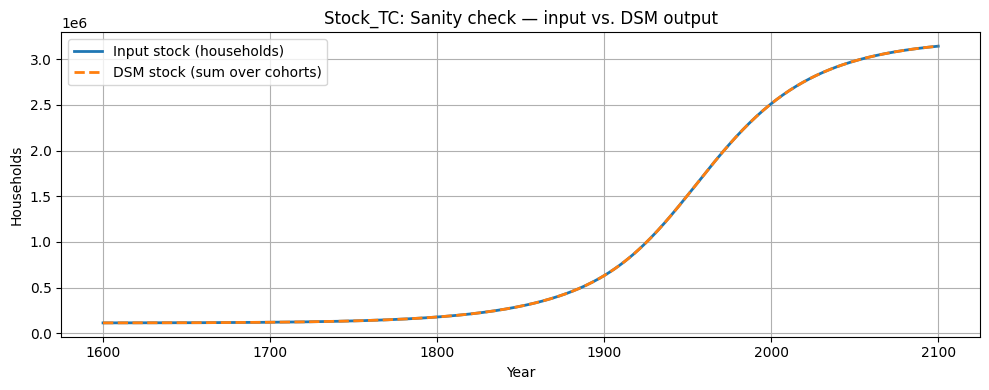

Max deviation: 0.00 households


In [6]:
# Stock_TC matrise: households in stock, indexed by [year, cohort]
# Rows = observation year (t), Columns = construction year (c)

Stock_TC = Stock_by_cohort_f  # shape (T, T)

# Note to self: stock per year (sum over cohorts) should match input stock 
stock_model_total = Stock_TC.sum(axis=1)  # sum over cohorts for each year

plt.figure(figsize=(10, 4))
plt.plot(time, stock, label='Input stock (households)', linewidth=2)
plt.plot(time, stock_model_total, '--', label='DSM stock (sum over cohorts)', linewidth=2)
plt.title('Stock_TC: Sanity check — input vs. DSM output')
plt.xlabel('Year')
plt.ylabel('Households')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f"Max deviation: {np.max(np.abs(stock - stock_model_total)):.2f} households")

In [7]:
# Lagre Stock_TC som DataFrame for videre bruk
# Rader = år, kolonner = kohort

Stock_TC_df = pd.DataFrame(
    Stock_TC,
    index=pd.Index(time, name='year'),
    columns=pd.Index(time, name='cohort')
)

print("Stock_TC shape:", Stock_TC_df.shape)
print(Stock_TC_df.iloc[:5, :5].round(1))  # preview

# Lagre til Excel for validering mot BYGB34
Stock_TC_df.to_excel("Stock_TC.xlsx")
print("Saved Stock_TC.xlsx")

Stock_TC shape: (501, 501)
cohort      1600  1601  1602  1603  1604
year                                    
1600    114643.8   0.0   0.0   0.0   0.0
1601    114643.0  20.1   0.0   0.0   0.0
1602    114642.2  20.1  20.6   0.0   0.0
1603    114641.2  20.1  20.6  21.2   0.0
1604    114640.1  20.1  20.6  21.2  21.8
Saved Stock_TC.xlsx


[1.14643761e+05 2.00507106e+01 2.05975434e+01 2.11730762e+01
 2.17802965e+01 2.24225488e+01 2.31035711e+01 2.38275354e+01
 2.45990906e+01 2.54234077e+01 2.63062289e+01 2.72539189e+01
 2.82735188e+01 2.93728028e+01 3.05603377e+01 3.18455440e+01
 3.32387590e+01 3.47513015e+01 3.63955378e+01 3.81849476e+01
 4.01341905e+01 4.22591715e+01 4.45771047e+01 4.71065752e+01
 4.98675971e+01 5.28816675e+01 5.61718150e+01 5.97626413e+01
 6.36803551e+01 6.79527963e+01 7.26094499e+01 7.76814476e+01
 8.32015556e+01 8.92041471e+01 9.57251588e+01 1.02802028e+02
 1.10473613e+02 1.18780088e+02 1.27762818e+02 1.37464214e+02
 1.47927559e+02 1.59196807e+02 1.71316365e+02 1.84330839e+02
 1.98284763e+02 2.13222290e+02 2.29186874e+02 2.46220911e+02
 2.64365366e+02 2.83659380e+02 3.04139846e+02 3.25840985e+02
 3.48793890e+02 3.73026072e+02 3.98560992e+02 4.25417595e+02
 4.53609835e+02 4.83146223e+02 5.14029366e+02 5.46255540e+02
 5.79814273e+02 6.14687960e+02 6.50851515e+02 6.88272054e+02
 7.26908629e+02 7.667120

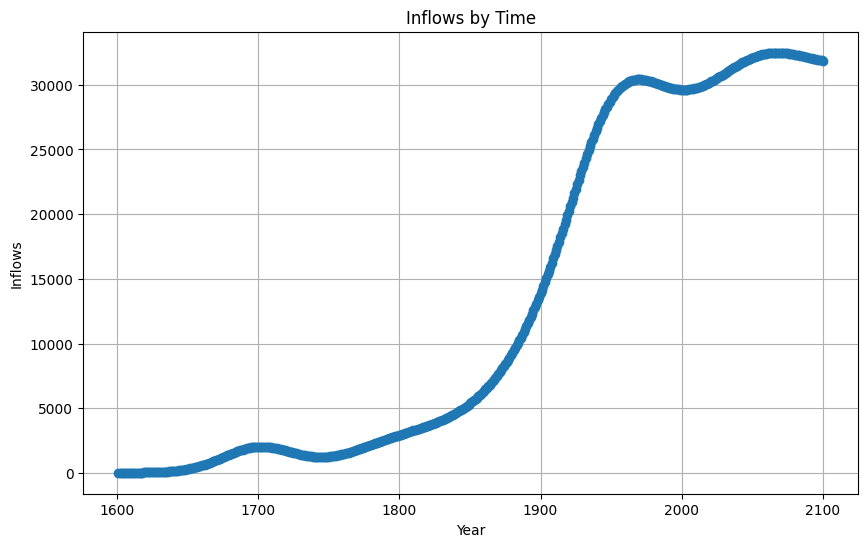

In [ ]:
print(Inflows_by_time_f)

# Plot inflows by time (drop the first spike value)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(time[0:], Inflows_by_time_f[1:], marker='o')

plt.title('Inflows by Time')
plt.xlabel('Year')
plt.ylabel('Inflows')
plt.grid()

plt.show()

In [26]:
print(stock[0])

114643.7606610232


In [27]:
Outflows_by_time, ExitFlag   = DSM.compute_outflow_total()

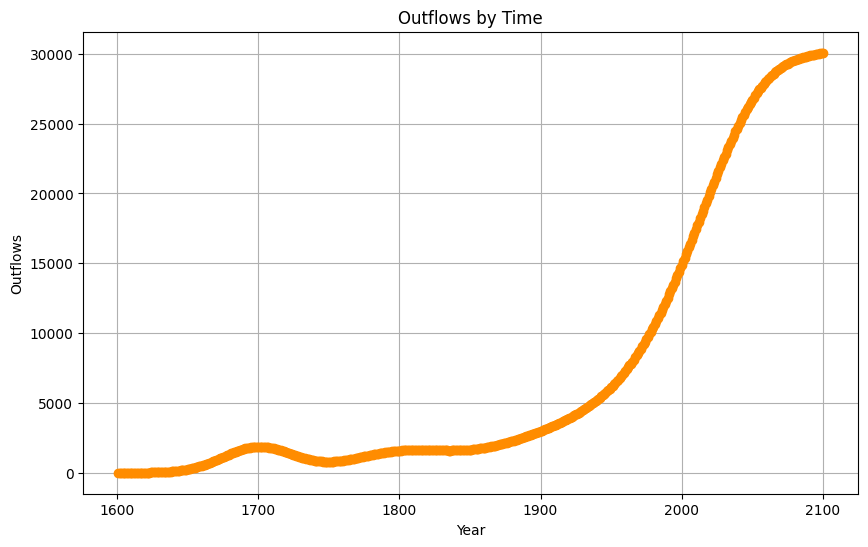

: 

In [ ]:
# Plot outflows by time (drop the first spike value)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(time[1:], Outflows_by_time[1:], marker='o', color='darkorange')

plt.title('Outflows by Time')
plt.xlabel('Year')
plt.ylabel('Outflows')
plt.grid()

plt.show()

In [20]:
inflow_validation_data = load_data("inflow_data_1939_2025.xlsx")
inflow_validation_data.head()

,"Den samlede byggeaktivitet (historisk oversigt) efter byggefase, tid og anvendelse",Unnamed: 1,Unnamed: 2
0,Enhed: M2,NaN,NaN
1,NaN,NaN,Beboelsesbygninger
2,Fuldførtbyggeri (1939 - ),1939.0,1554337
3,NaN,1940.0,921893
4,NaN,1941.0,551906
